In [25]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [26]:
#Data loading & inspection
facebook_ads_data=fad_df=pd.read_csv('facebook_ads_data.csv')
print(fad_df.head())
print(fad_df.info())

      ad_date campaign_name  total_spend  total_impressions  total_clicks  \
0  2022-11-05     Expansion         0.00                  0             0   
1  2022-11-01     Expansion         0.00                  0             0   
2  2022-10-31     Expansion       227.45               6054            58   
3  2022-10-30     Expansion       335.91              27562            69   
4  2022-10-29     Expansion       714.03              33358           115   

   total_value   cpc    cpm       ctr      romi  
0         0.00   NaN    NaN       NaN       NaN  
1         0.00   NaN    NaN       NaN       NaN  
2       191.87  3.92  37.57  0.009580  0.843570  
3       472.61  4.87  12.19  0.002503  1.406954  
4       680.34  6.21  21.41  0.003447  0.952817  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-n

#### Daily Ad Spend Trends
##### Technical Action:
##### Performed data type conversion to datetime and filtered the dataset for the year 2021.
##### Aggregated marketing spend on a daily basis to identify investment patterns.
##### Business Insight: 
##### This visualization helps identify spending volatility and seasonal peaks.
##### By monitoring daily spend, we can correlate sudden spikes with specific marketing campaigns or external events (e.g., holidays or sales).

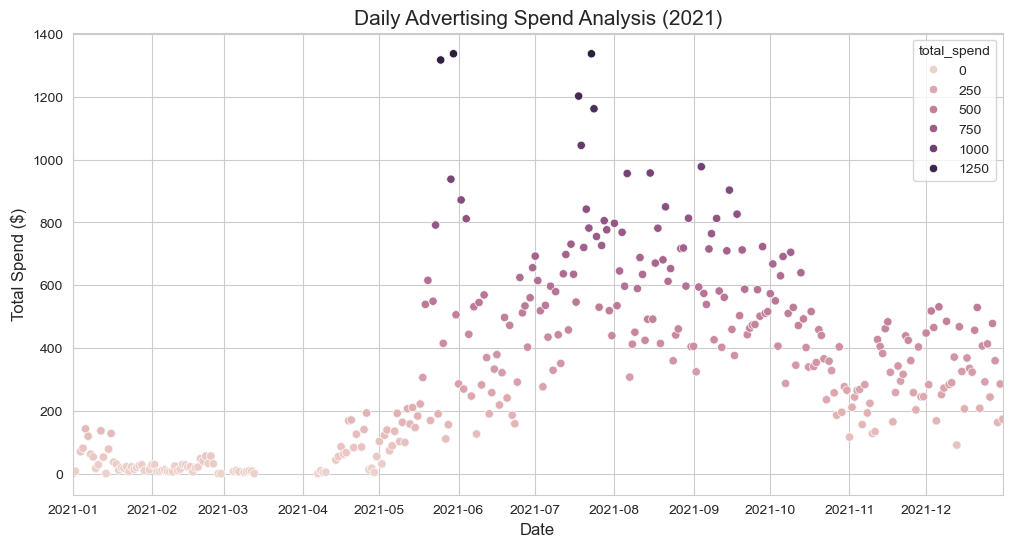

In [27]:
# Grouping by date
fad_df['ad_date'] = pd.to_datetime(fad_df['ad_date'])
df_2021 = fad_df[fad_df['ad_date'].dt.year == 2021]
daily_spend = df_2021.groupby('ad_date', as_index=False)['total_spend'].sum()

# Visualization 
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=daily_spend, 
    x='ad_date', 
    y='total_spend', 
    hue='total_spend', 
    palette='viridis', 
    legend=False
)

ax = sns.scatterplot(x=daily_spend.ad_date, y=daily_spend.total_spend, hue=daily_spend.total_spend)
plt.title('Daily Advertising Spend Analysis (2021)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-12-31'))

plt.savefig('C:/Users/User/Desktop/resume/images/Daily Ad Spend Trends.png')
plt.show()

#### Marketing Investment Efficiency (ROMI)
##### Technical Action:   
##### Calculated daily ROMI (Return on Marketing Investment) to evaluate the profitability of ad campaigns.
##### Applied a 7-day rolling average to smooth out daily fluctuations and identify long-term efficiency trends.
##### Business Insight:
##### Throughout 2021, the ROMI remained consistently positive, indicating that all advertising efforts effectively generated revenue exceeding the ad spend.
##### Even during periods of high spending volatility, the rolling average stayed well above the breakeven point, demonstrating a robust and profitable marketing strategy.

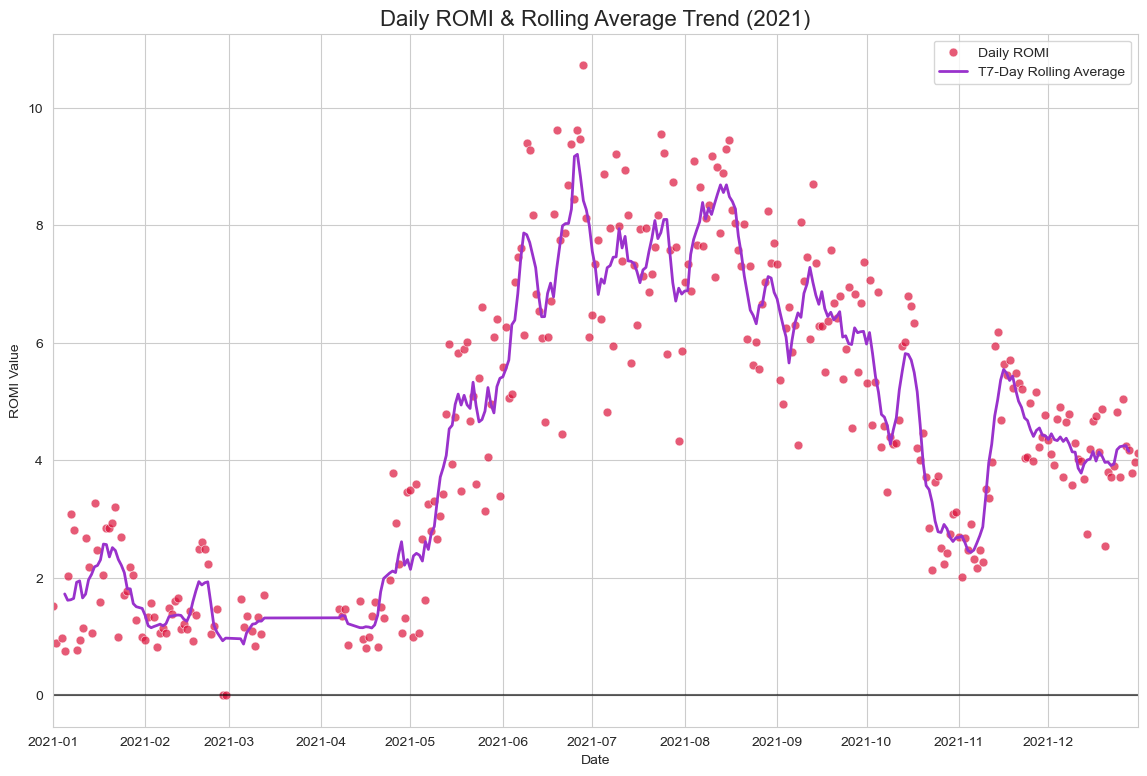

In [28]:
# Grouping by date and summing ROMI
daily_data = df_2021.groupby('ad_date', as_index=False)['romi'].sum()

# Calculating 7-day rolling average (moving average)
daily_data['romi_rolling'] = daily_data['romi'].rolling(window=7, center=True).mean()

# Visualization
plt.figure(figsize=(14, 9))

# Scatterplot for daily values
sns.scatterplot(
    data=daily_data, 
    x='ad_date', 
    y='romi', 
    alpha=0.7,           
    s=40,               
    label='Daily ROMI',
    color='crimson'
)

# Lineplot for the trend
sns.lineplot(
    data=daily_data, 
    x='ad_date', 
    y='romi_rolling', 
    color='darkorchid', 
    linewidth=2, 
    label='Т7-Day Rolling Average'
)

plt.axhline(0, color='black', linestyle='-', alpha=0.6) 
plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-12-31'))
plt.title('Daily ROMI & Rolling Average Trend (2021)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('ROMI Value')
plt.legend()

plt.savefig('C:/Users/User/Desktop/resume/images/Daily ROMI & Rolling Average Trend (2021).png')
plt.show()

#### Campaign Budget Allocation
##### Technical Action:
##### Aggregated the total advertising expenditure across different marketing campaigns using groupby.
##### Visualized the budget distribution to identify the primary drivers of marketing costs.
##### Business Insight:
##### This bar chart clearly shows which campaigns are the top budget consumers.

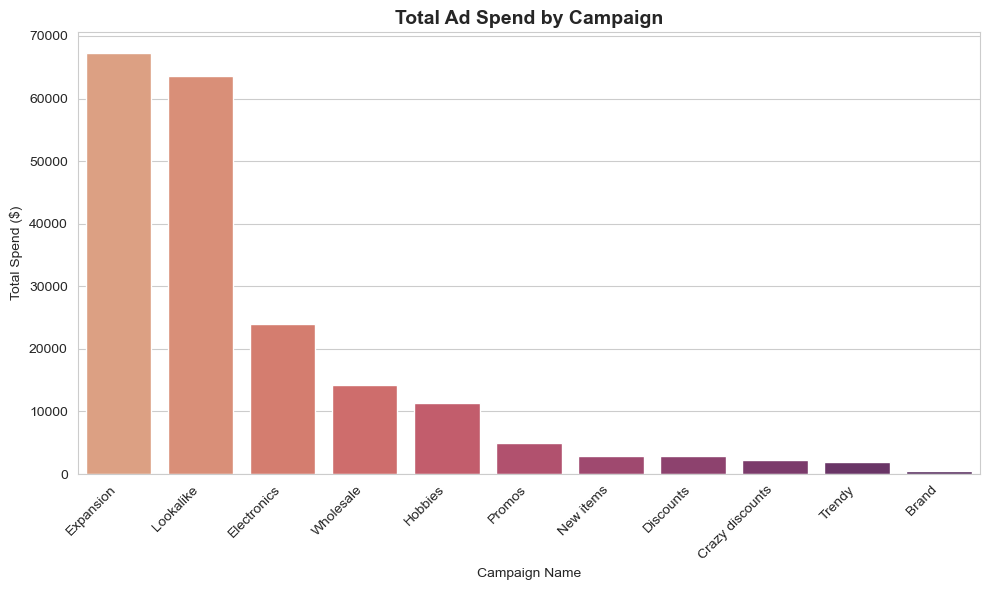

In [29]:
# Grouping by campaign_name to see total investments
ttl_spend = fad_df.groupby('campaign_name', as_index=False)['total_spend'].sum()

# Sort data for better visualization (optional but recommended)
ttl_spend = ttl_spend.sort_values('total_spend', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ttl_spend, 
    x='campaign_name',   
    y='total_spend',
    hue='campaign_name',
    palette='flare',
    legend=False # Removes redundant legend
)

plt.xticks(rotation=45, ha='right')
plt.title('Total Ad Spend by Campaign', fontsize=14, fontweight='bold')
plt.xlabel('Campaign Name')
plt.ylabel('Total Spend ($)')

plt.tight_layout()
plt.savefig('C:/Users/User/Desktop/resume/images/Total Ad Spend by Campaign.png')
plt.show()

#### Campaign Efficiency Analysis (Mean ROMI)
##### Technical Action:
##### Used the .groupby() method combined with .mean() to calculate the Average ROMI for each campaign.
##### Fair Comparison: Unlike total sum, using the average allows for a fair performance evaluation between long-term and short-term (e.g., seasonal) campaigns.
##### Sorting: Applied .sort_values() to rank campaigns from most to least efficient, providing a clear hierarchy for decision-making.
##### Business Insight:
##### This visualization shows which marketing channels deliver the highest return for every dollar spent.
##### Campaigns with high average ROMI but lower total spend (identified in previous steps) are prime candidates for budget scaling
##### Campaigns with below-average ROMI require further investigation into creative quality or audience targeting to improve overall account health

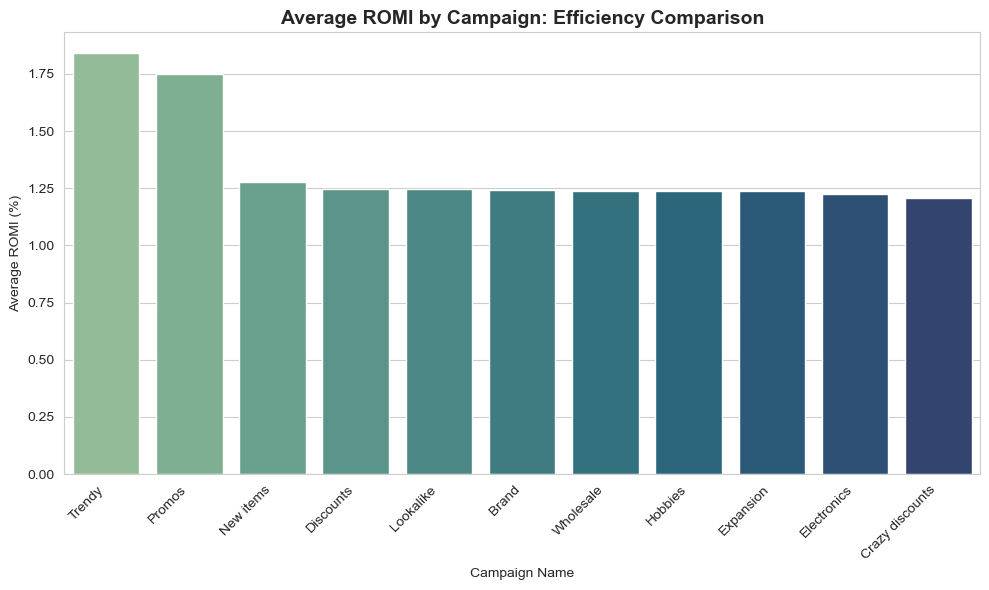

In [36]:
# Calculating the average ROMI to compare campaign performance fairly
campaign_efficiency = fad_df.groupby('campaign_name', as_index=False)['romi'].mean()

# Sorting by efficiency (highest ROMI first)
campaign_efficiency = campaign_efficiency.sort_values('romi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=campaign_efficiency, 
    x='campaign_name',   
    y='romi',
    hue='campaign_name',
    palette='crest',
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Average ROMI by Campaign: Efficiency Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Campaign Name')
plt.ylabel('Average ROMI (%)')

plt.tight_layout()
plt.savefig('C:/Users/User/Desktop/resume/images/Average ROMI by Campaign.png')
plt.show()

#### Campaign Stability & Risk Assessment
##### Technical Action:
##### Implemented a Boxplot visualization to analyze the distribution and variance of ROMI across different campaigns.
##### Identified medians, quartiles, and potential outliers in daily performance.
##### Business Insight:
##### Promos: High ROMI spikes correlate with limited-time offers. This indicates a high price sensitivity of the audience—they respond aggressively to discounts.
##### Trendy: The high volatility reflects the short lifecycle of viral products. These campaigns drive exceptional returns during the peak of interest but require constant monitoring to avoid overspending when the trend fades.
##### Risk Management: By looking at the "whiskers" relative to the Breakeven Point (0%), we can see which campaigns are at risk of falling into negative ROI.

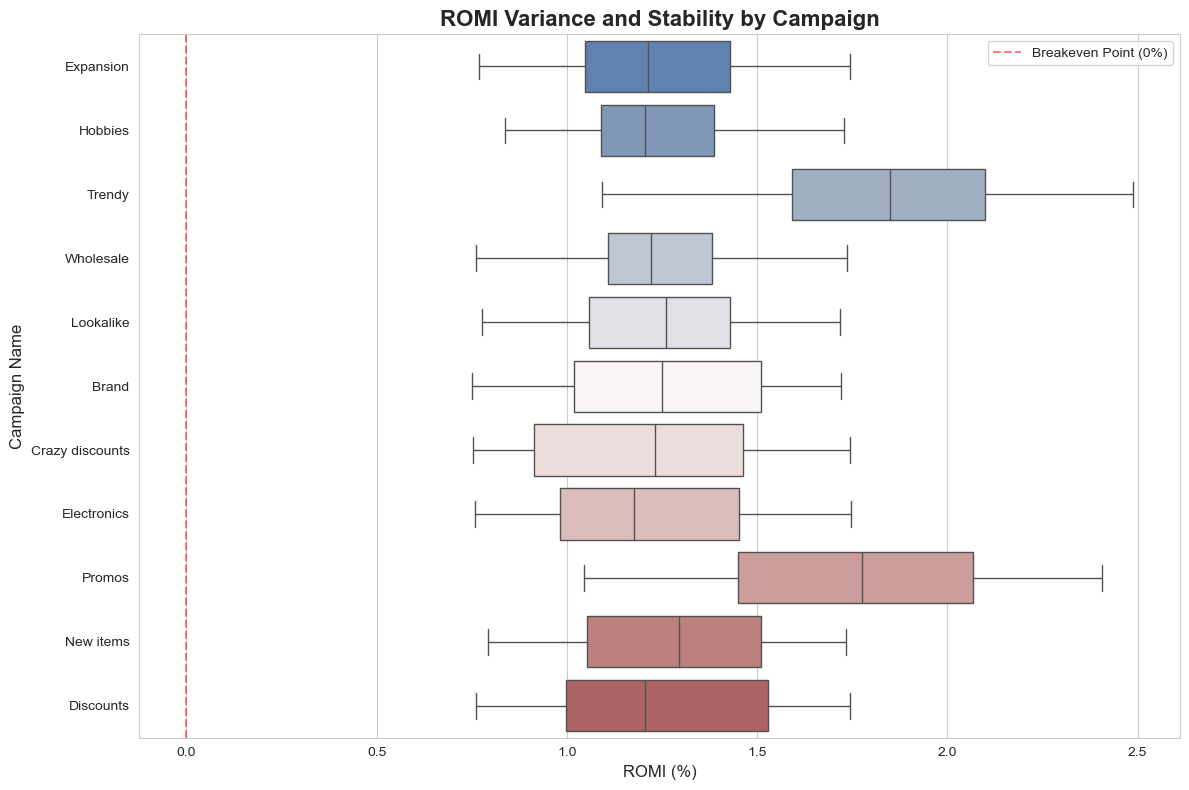

In [31]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Creating the boxplot
sns.boxplot(
    data=fad_df, 
    x='romi', 
    y='campaign_name', 
    hue='campaign_name',
    palette='vlag',
    legend=False
)

# Reference line for breakeven point
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Breakeven Point (0%)')


plt.title('ROMI Variance and Stability by Campaign', fontsize=16, fontweight='bold')
plt.xlabel('ROMI (%)', fontsize=12)
plt.ylabel('Campaign Name', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('C:/Users/User/Desktop/resume/images/ROMI Variance and Stability by Campaign.png')
plt.show()

#### Correlation & Regression Analysis
##### Technical Action:
##### Performed a Linear Regression analysis using sns.lmplot to model the relationship between total_spend (Independent Variable) and total_value (Dependent Variable).
##### Visualized the confidence interval and the "line of best fit" to determine how consistently spending leads to revenue.
##### Business Insight:
##### The slope of the red line shows the efficiency of our spending. A steep upward slope indicates that increasing the budget effectively drives more revenue.
##### The closer the blue dots (actual data) are to the red line, the more predictable our marketing results are.
##### If we saw the dots "fanning out" at higher spend levels, it would suggest that simply throwing more money at ads becomes less effective over time. In this dataset, we can identify the optimal spending range where the return is most consistent.

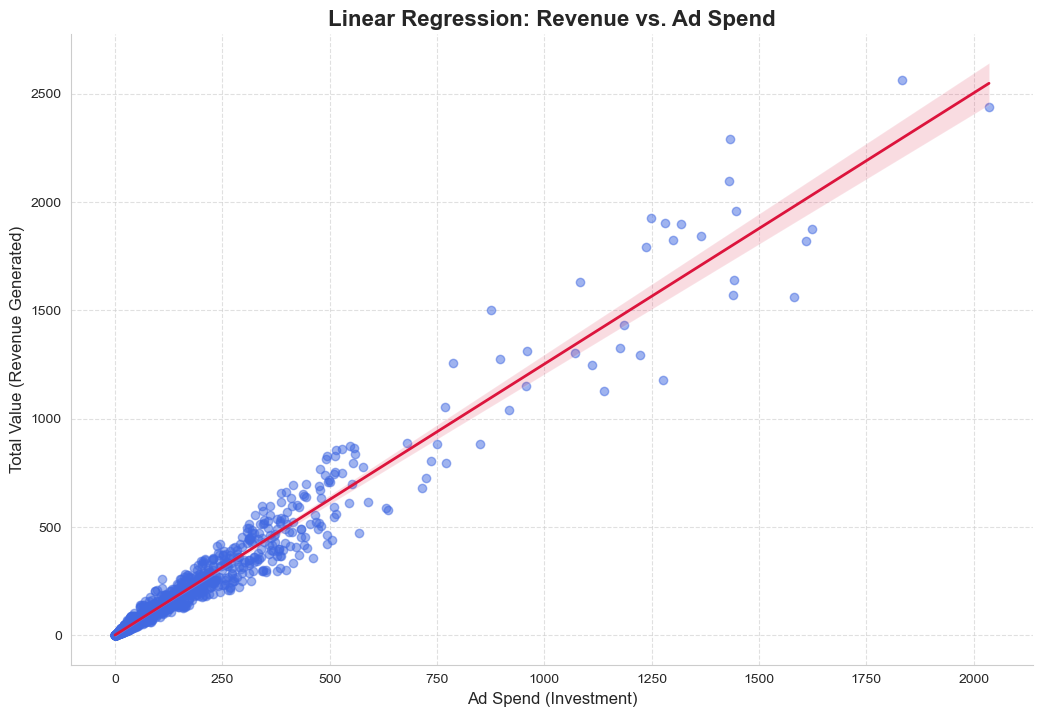

In [35]:
sns.lmplot(
    data=fad_df,
    x='total_spend',  
    y='total_value',  
    height=7,         
    aspect=1.5,      
    scatter_kws={'alpha': 0.5, 'color': 'royalblue'}, 
    line_kws={'color': 'crimson', 'linewidth': 2}    
)

plt.title('Linear Regression: Revenue vs. Ad Spend', fontsize=16, fontweight='bold')
plt.xlabel('Ad Spend (Investment)', fontsize=12)
plt.ylabel('Total Value (Revenue Generated)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('C:/Users/User/Desktop/resume/images/Linear Regression.png')
plt.show()